In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

In [6]:
df=pd.read_csv("auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [7]:
df=df.replace('?', np.nan)
df["horsepower"] = pd.to_numeric(df["horsepower"])
df=df.dropna()

In [8]:
X=df[['horsepower', 'weight', 'displacement']]
Y=df[['mpg']]

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [10]:
alpha_values=[0, 0.1, 1, 10, 100]
print("RIDGE REGRESSION COEFFICIENT\n")

for alpha_value in alpha_values:
    ridge_model=Ridge(alpha=alpha_value)

    ridge_model.fit(X_train, Y_train)
    print(f"Alpha ={alpha_value}")
    print(pd.Series(ridge_model.coef_, index=X.columns))
    print("-" * 40)

RIDGE REGRESSION COEFFICIENT

Alpha =0
horsepower     -0.043286
weight         -0.005209
displacement   -0.008812
dtype: float64
----------------------------------------
Alpha =0.1
horsepower     -0.043286
weight         -0.005209
displacement   -0.008812
dtype: float64
----------------------------------------
Alpha =1
horsepower     -0.043286
weight         -0.005209
displacement   -0.008812
dtype: float64
----------------------------------------
Alpha =10
horsepower     -0.043282
weight         -0.005209
displacement   -0.008813
dtype: float64
----------------------------------------
Alpha =100
horsepower     -0.043241
weight         -0.005209
displacement   -0.008822
dtype: float64
----------------------------------------


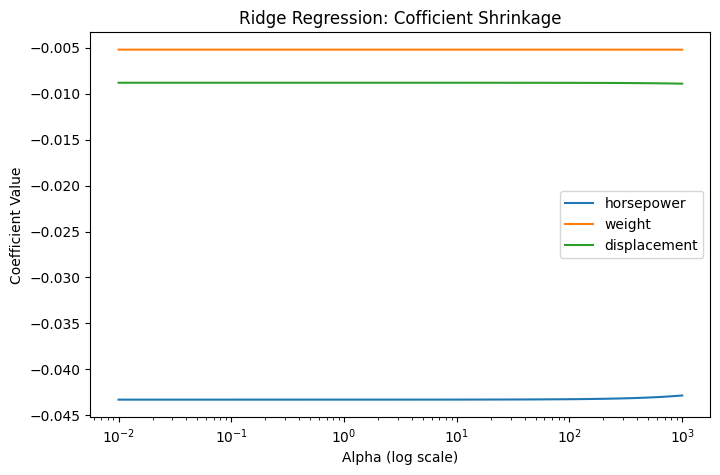

In [11]:
alphas= np.logspace(-2, 3, 50)

coefficients_path=[]

for alpha_value in alphas:
    ridge=Ridge(alpha=alpha_value)
    ridge.fit(X_train, Y_train)
    coefficients_path.append(ridge.coef_)

coefficients_path=np.array(coefficients_path)

plt.figure(figsize=(8, 5))
plt.plot(alphas, coefficients_path)
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficient Value")
plt.title("Ridge Regression: Cofficient Shrinkage")
plt.legend(X.columns)

In [13]:
print("LASSO REGRESSION COEFFICIENT\n")

for alpha_value in [0.01, 0.1, 1, 10]:
    lasso_model=Lasso(alpha=alpha_value, max_iter=5000)

    lasso_model.fit(X_train, Y_train)
    print(f"Alpha ={alpha_value}")
    print(pd.Series(lasso_model.coef_, index=X.columns))
    print("-" * 40)

LASSO REGRESSION COEFFICIENT

Alpha =0.01
horsepower     -0.043261
weight         -0.005210
displacement   -0.008813
dtype: float64
----------------------------------------
Alpha =0.1
horsepower     -0.043023
weight         -0.005218
displacement   -0.008820
dtype: float64
----------------------------------------
Alpha =1
horsepower     -0.040731
weight         -0.005299
displacement   -0.008884
dtype: float64
----------------------------------------
Alpha =10
horsepower     -0.017906
weight         -0.006100
displacement   -0.009540
dtype: float64
----------------------------------------


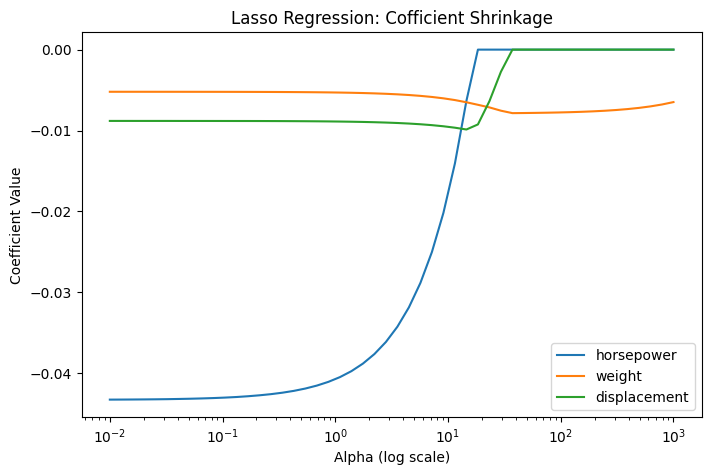

In [11]:
alphas= np.logspace(-2, 3, 50)

coefficients_path=[]

for alpha_value in alphas:
    lasso=Lasso(alpha=alpha_value)
    lasso.fit(X_train, Y_train)
    coefficients_path.append(lasso.coef_)

coefficients_path=np.array(coefficients_path)

plt.figure(figsize=(8, 5))
plt.plot(alphas, coefficients_path)
plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Regression: Cofficient Shrinkage")
plt.legend(X.columns)

In [12]:
param_grid={'alpha': np.logspace(-3, 2, 20)}

ridge_cv=GridSearchCV(
    Ridge(),
    param_grid, 
    scoring='neg_mean_squared_error'
)
ridge_cv.fit(X_train, Y_train)
print("Best Alpha (Ridge):", ridge_cv.best_params_['alpha'])

Best Alpha (Ridge): 100.0


In [13]:
lasso_cv=GridSearchCV(
    Lasso(max_iter=5000),
    param_grid,
    scoring='neg_mean_squared_error'
)
lasso_cv.fit(X_train, Y_train)
print("Best Alpha (Lasso):", lasso_cv.best_params_['alpha'])

Best Alpha (Lasso): 0.001


In [14]:
best_ridge=ridge_cv.best_estimator_
best_lasso=lasso_cv.best_estimator_

ridge_pred= best_ridge.predict(X_test)
lasso_pred= best_lasso.predict(X_test)

print("Ridge MSE:", mean_squared_error(Y_test, ridge_pred))
print("Lasso MSE:", mean_squared_error(Y_test, lasso_pred))

Ridge MSE: 18.013642097762364
Lasso MSE: 18.013869478647997


In [15]:
print("Ridge R² Score:", r2_score(Y_test, ridge_pred))
print("Lasso R² Score:", r2_score(Y_test, lasso_pred))

Ridge R² Score: 0.6470721736640981
Lasso R² Score: 0.6470677187603489


In [16]:
print("Final Ridge Coefficients:")
print(pd.Series(best_ridge.coef_, index=X.columns))

print("\nFinal Lasso Coefficients:")
print(pd.Series(best_lasso.coef_, index=X.columns))

Final Ridge Coefficients:
horsepower     -0.043241
weight         -0.005209
displacement   -0.008822
dtype: float64

Final Lasso Coefficients:
horsepower     -0.043284
weight         -0.005209
displacement   -0.008812
dtype: float64


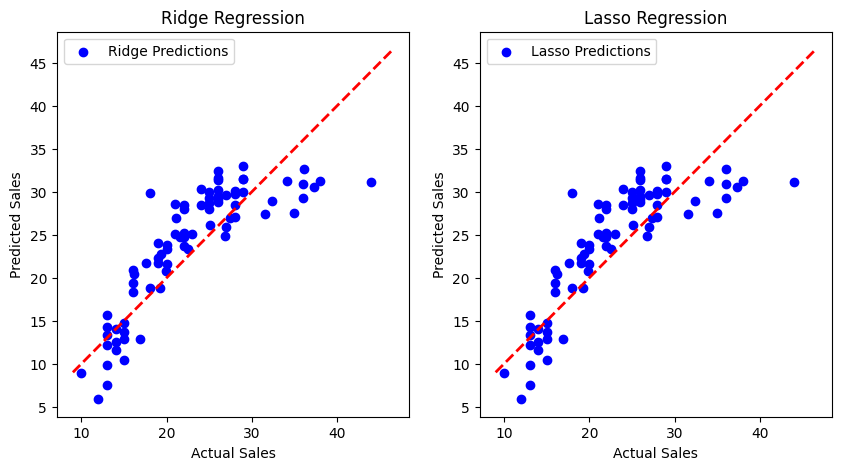

In [17]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(Y_test, ridge_pred, color='blue', label="Ridge Predictions")
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Ridge Regression")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(Y_test, lasso_pred, color='blue', label="Lasso Predictions")
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Lasso Regression")
plt.legend()